Test Accuracy: 0.9635


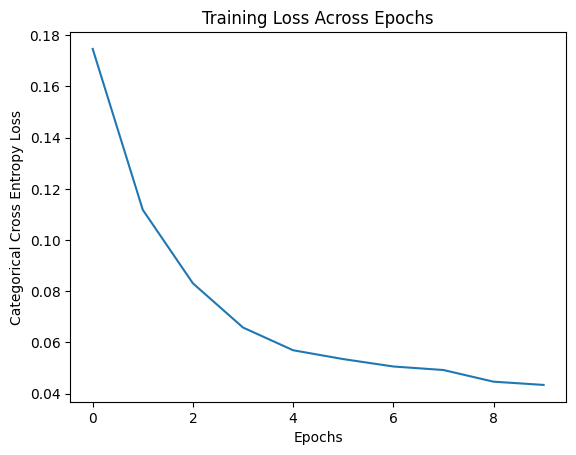

In [2]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
from sklearn.exceptions import ConvergenceWarning

# Step 2: Ignore Convergence Warning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Step 3: Load MNIST Dataset
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target.astype(int)

# Step 4: Normalize Data
X = X / 255.0

# Step 5: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: One Hot Encoding
lb = LabelBinarizer()

y_train_cat = lb.fit_transform(y_train)
y_test_cat = lb.transform(y_test)

# Step 7: Create Model
model = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation='relu',
    solver='adam',
    max_iter=1,
    warm_start=True,
    random_state=42
)

# Step 8: Train Model for Multiple Epochs
epochs = 10
loss_values = []

for i in range(epochs):

    model.fit(X_train, y_train)

    prob = model.predict_proba(X_train)

    loss = log_loss(y_train_cat, prob)

    loss_values.append(loss)

# Step 9: Test Accuracy
accuracy = model.score(X_test, y_test)

print("Test Accuracy:", accuracy)

# Step 10: Plot Training Loss
plt.plot(loss_values)

plt.title("Training Loss Across Epochs")
plt.xlabel("Epochs")
plt.ylabel("Categorical Cross Entropy Loss")

plt.show()